# Attacker Band: Naive vs Adaptive

This notebook produces the privacy-leak **band** between two threat models:

  * `clean_attacker` (naive lower bound): attacker trained on CLEAN ECG
    signals, evaluated on DP-perturbed signals. Represents a less
    sophisticated attacker who did not anticipate the privacy mechanism.

  * `adaptive_attacker` (adaptive upper bound): attacker trained AND
    evaluated on DP-perturbed signals at the same (mechanism, eps, delta).
    Represents a worst-case attacker who knows the privacy mechanism and
    adapts to it.

These two curves give an **honest privacy-leak interval** for each (mech,
eps). A small gap between naive and adaptive means the privacy guarantee
is robust to attacker sophistication; a large gap means a sophisticated
attacker gains substantial advantage.

Both bounds are loaded from the same Re-ID layout used by Notebook 02:
  `results/reid/dp/<mech>/eps_<e>_delta_<d>/<threat_model>/seed_<S>/metrics.pkl`
with `<threat_model>` in {`clean_attacker`, `adaptive_attacker`}.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _loader import (
    load_utility_baseline, load_utility_sweep,
    load_reid_baseline, load_reid_sweep,
)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'savefig.bbox': 'tight', 'figure.constrained_layout.use': False,
})

RESULTS = Path('../results')
FIGURES = Path('../results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {
    'laplace': 'Laplace',
    'laplace_bounded': 'Bounded Laplace',
    'gaussian_analytic': 'Analytic Gaussian',
}
MECH_MARKERS = {
    'laplace': 'o',
    'laplace_bounded': 's',
    'gaussian_analytic': '^',
}
MECH_COLORS = {
    'laplace': '#1f77b4',
    'laplace_bounded': '#ff7f0e',
    'gaussian_analytic': '#2ca02c',
}

## Load both threat models

In [2]:
util_baseline = load_utility_baseline(RESULTS)
util_sweep = load_utility_sweep(RESULTS)
reid_mit_baseline = load_reid_baseline(RESULTS / 'reid')
reid_mit_sweep = load_reid_sweep(RESULTS / 'reid')
reid_ecg_baseline = load_reid_baseline(RESULTS / 'reid_ecgid')
reid_ecg_sweep = load_reid_sweep(RESULTS / 'reid_ecgid')

print(f'Utility sweep rows:    {len(util_sweep)}')
print(f'MIT-BIH Re-ID rows:    {len(reid_mit_sweep)}')
print(f'ECG-ID Re-ID rows:     {len(reid_ecg_sweep)}')
print()
print('Threat models present in MIT-BIH:', sorted(reid_mit_sweep['threat_model'].unique()))
print('Threat models present in ECG-ID: ', sorted(reid_ecg_sweep['threat_model'].unique()))

if 'clean_attacker' not in reid_mit_sweep['threat_model'].values:
    print()
    print('WARNING: No clean_attacker results found in results/reid/.')
    print('Run: bash run_naive_attacker.sh')

# Baseline references
util_baseline_macro = util_baseline['macro_f1'].mean() if not util_baseline.empty else np.nan
reid_mit_random = reid_mit_baseline['random_baseline'].iloc[0] if not reid_mit_baseline.empty else np.nan
reid_ecg_random = reid_ecg_baseline['random_baseline'].iloc[0] if not reid_ecg_baseline.empty else np.nan

Utility sweep rows:    162
MIT-BIH Re-ID rows:    525
ECG-ID Re-ID rows:     525

Threat models present in MIT-BIH: ['adaptive_attacker', 'adaptive_denoise_savgol', 'clean_attacker']
Threat models present in ECG-ID:  ['adaptive_attacker', 'adaptive_denoise_savgol', 'clean_attacker']


In [3]:
# Aggregate Re-ID per (mech, eps, threat_model) over seeds
def agg_reid_per_tmode(df):
    return (
        df.groupby(['mechanism', 'eps', 'delta', 'threat_model'])
        ['reid_accuracy'].agg(['mean', 'std']).reset_index()
        .rename(columns={'mean': 'reid_mean', 'std': 'reid_std'})
    )

reid_mit_agg = agg_reid_per_tmode(reid_mit_sweep)
reid_ecg_agg = agg_reid_per_tmode(reid_ecg_sweep)
util_agg = (
    util_sweep.groupby(['mechanism', 'eps', 'delta'])
    ['macro_f1'].agg(['mean', 'std']).reset_index()
    .rename(columns={'mean': 'util_mean', 'std': 'util_std'})
)

print('MIT-BIH Re-ID per threat model:')
print(reid_mit_agg.groupby('threat_model').size())
print()
print('ECG-ID Re-ID per threat model:')
print(reid_ecg_agg.groupby('threat_model').size())

MIT-BIH Re-ID per threat model:
threat_model
adaptive_attacker          54
adaptive_denoise_savgol    46
clean_attacker             45
dtype: int64

ECG-ID Re-ID per threat model:
threat_model
adaptive_attacker          54
adaptive_denoise_savgol    46
clean_attacker             45
dtype: int64


## Figure A: Attacker band per database (Re-ID vs eps)

Lower curve = naive attacker, upper curve = adaptive attacker.
Filled area between them = privacy-leak band — the *range* of risk
depending on attacker sophistication.

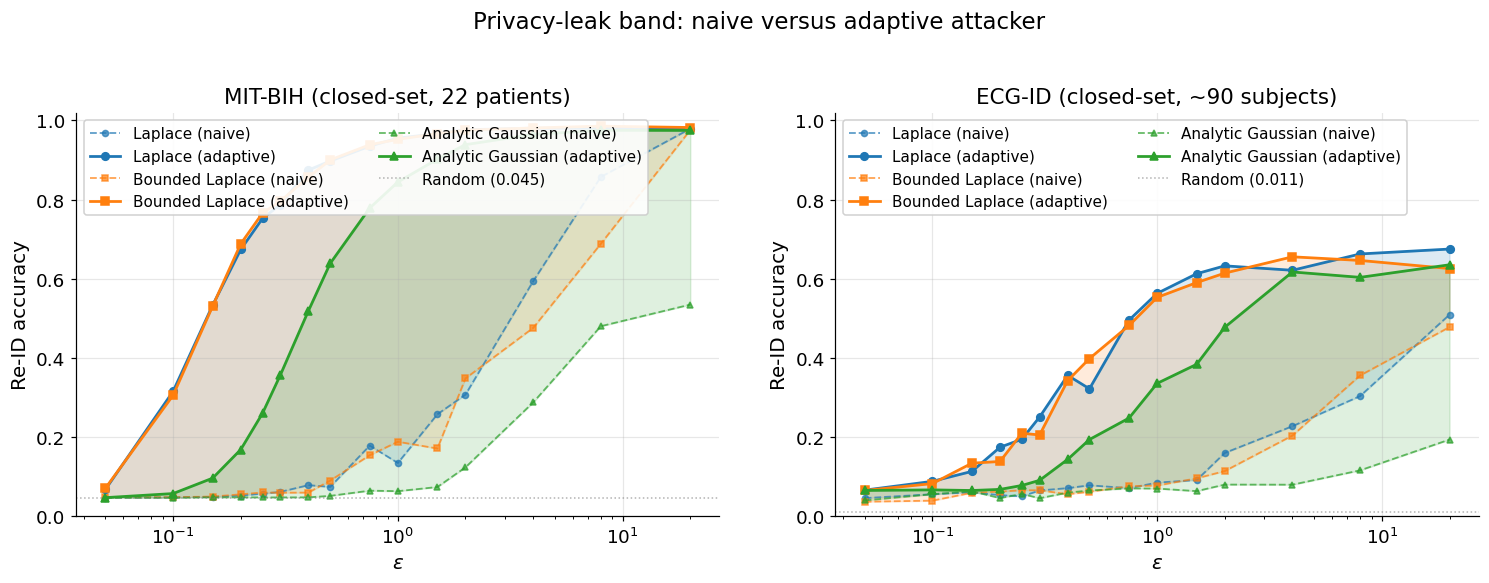

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for ax, agg_df, ds_label, random_acc in zip(
    axes,
    [reid_mit_agg, reid_ecg_agg],
    ['MIT-BIH (closed-set, 22 patients)', 'ECG-ID (closed-set, ~90 subjects)'],
    [reid_mit_random, reid_ecg_random],
):
    if agg_df.empty:
        ax.set_title(f'{ds_label} (no data)')
        continue

    for mech in MECH_LABELS:
        color = MECH_COLORS[mech]
        naive = agg_df[(agg_df['mechanism'] == mech) &
                       (agg_df['threat_model'] == 'clean_attacker')].sort_values('eps')
        adapt = agg_df[(agg_df['mechanism'] == mech) &
                       (agg_df['threat_model'] == 'adaptive_attacker')].sort_values('eps')
        # We need both for a band
        if naive.empty or adapt.empty:
            # Plot what we have as single curve
            curve = naive if not naive.empty else adapt
            ax.plot(curve['eps'], curve['reid_mean'], marker=MECH_MARKERS[mech],
                    color=color, linewidth=1.6, markersize=5,
                    label=f'{MECH_LABELS[mech]} (single)', alpha=0.9)
            continue

        # Align on eps (some configs may be missing on one side)
        merged = naive[['eps', 'reid_mean', 'reid_std']].rename(
            columns={'reid_mean': 'naive_mean', 'reid_std': 'naive_std'}
        ).merge(
            adapt[['eps', 'reid_mean', 'reid_std']].rename(
                columns={'reid_mean': 'adapt_mean', 'reid_std': 'adapt_std'}
            ),
            on='eps', how='inner'
        ).sort_values('eps')

        # Band between naive (lower) and adaptive (upper)
        ax.fill_between(merged['eps'], merged['naive_mean'], merged['adapt_mean'],
                         color=color, alpha=0.15, zorder=1)
        # Naive: dashed lower curve
        ax.plot(merged['eps'], merged['naive_mean'], '--',
                color=color, marker=MECH_MARKERS[mech], linewidth=1.2, markersize=4,
                alpha=0.7, zorder=2,
                label=f'{MECH_LABELS[mech]} (naive)')
        # Adaptive: solid upper curve
        ax.plot(merged['eps'], merged['adapt_mean'], '-',
                color=color, marker=MECH_MARKERS[mech], linewidth=1.8, markersize=5,
                alpha=1.0, zorder=3,
                label=f'{MECH_LABELS[mech]} (adaptive)')

    if not np.isnan(random_acc):
        ax.axhline(random_acc, color='gray', linestyle=':', alpha=0.6,
                   linewidth=1, label=f'Random ({random_acc:.3f})')

    ax.set_xscale('log')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel('Re-ID accuracy')
    ax.set_title(ds_label)
    ax.set_ylim(0, 1.02)
    ax.legend(loc='upper left', fontsize=10, ncol=2, framealpha=0.9)

fig.suptitle('Privacy-leak band: naive versus adaptive attacker', y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES / 'attacker_band_per_database.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'attacker_band_per_database.png', bbox_inches='tight')
plt.show()

## Figure B: Money figure as a band

Same idea as Notebook 02 but each (mech, eps) is shown as a horizontal
segment from naive Re-ID (left) to adaptive Re-ID (right). The segment
length encodes how much an attacker gains from adapting to DP.

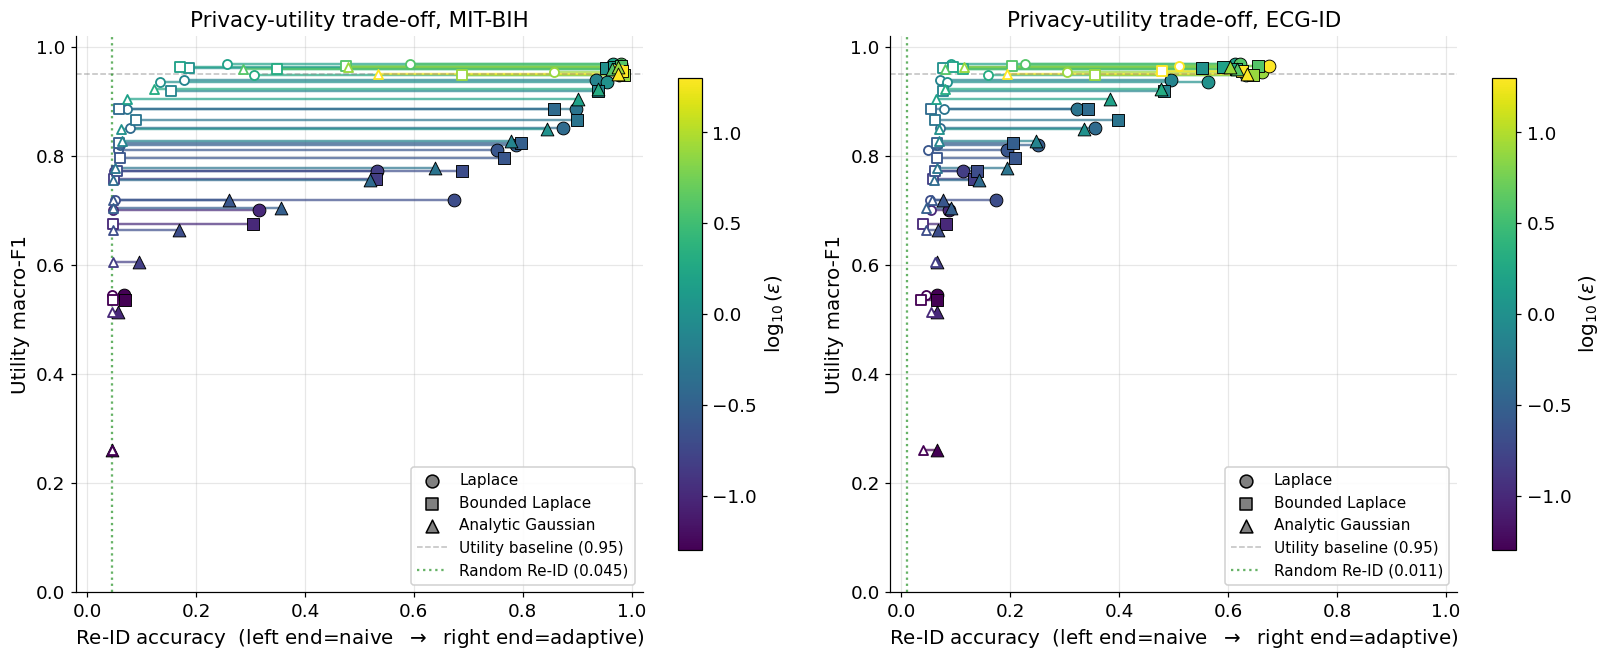

In [5]:
def build_segments(reid_agg_db, util_agg_in):
    naive = (reid_agg_db[reid_agg_db['threat_model'] == 'clean_attacker']
             [['mechanism','eps','delta','reid_mean','reid_std']]
             .rename(columns={'reid_mean': 'naive_mean', 'reid_std': 'naive_std'}))
    adapt = (reid_agg_db[reid_agg_db['threat_model'] == 'adaptive_attacker']
             [['mechanism','eps','delta','reid_mean','reid_std']]
             .rename(columns={'reid_mean': 'adapt_mean', 'reid_std': 'adapt_std'}))
    seg = naive.merge(adapt, on=['mechanism','eps','delta'], how='inner')
    seg = seg.merge(util_agg_in, on=['mechanism','eps','delta'], how='inner')
    return seg

seg_mit = build_segments(reid_mit_agg, util_agg)
seg_ecg = build_segments(reid_ecg_agg, util_agg)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

for ax, seg, ds_label, random_acc in zip(
    axes,
    [seg_mit, seg_ecg],
    ['MIT-BIH', 'ECG-ID'],
    [reid_mit_random, reid_ecg_random],
):
    if seg.empty:
        ax.set_title(f'{ds_label} (no naive-attacker data)')
        continue
    eps_vals = sorted(seg['eps'].unique())
    log_eps_all = np.log10(np.array(eps_vals))
    norm = plt.Normalize(vmin=log_eps_all.min(), vmax=log_eps_all.max())
    cmap = plt.cm.viridis

    for mech in MECH_LABELS:
        sub = seg[seg['mechanism'] == mech]
        if sub.empty:
            continue
        for _, row in sub.iterrows():
            col = cmap(norm(np.log10(row['eps'])))
            # Segment from naive to adaptive on x
            ax.plot([row['naive_mean'], row['adapt_mean']],
                    [row['util_mean'], row['util_mean']],
                    color=col, linewidth=1.6, alpha=0.7, zorder=2)
            # Marker at adaptive end (worst case)
            ax.scatter(row['adapt_mean'], row['util_mean'],
                       marker=MECH_MARKERS[mech], color=col,
                       s=70, edgecolor='black', linewidth=0.6, zorder=3)
            # Small open circle at naive end
            ax.scatter(row['naive_mean'], row['util_mean'],
                       marker=MECH_MARKERS[mech], facecolor='white',
                       edgecolor=col, s=35, linewidth=1.2, zorder=3)

    # Legend for shapes
    for mech in MECH_LABELS:
        ax.scatter([], [], marker=MECH_MARKERS[mech], s=70,
                   facecolor='gray', edgecolor='black',
                   label=MECH_LABELS[mech])
    if not np.isnan(util_baseline_macro):
        ax.axhline(util_baseline_macro, color='gray', linestyle='--',
                   linewidth=1, alpha=0.5, label=f'Utility baseline ({util_baseline_macro:.2f})')
    if not np.isnan(random_acc):
        ax.axvline(random_acc, color='green', linestyle=':',
                   alpha=0.6, label=f'Random Re-ID ({random_acc:.3f})')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax, label=r'$\log_{10}(\varepsilon)$', shrink=0.85)
    ax.set_xlabel(r'Re-ID accuracy  (left end=naive  $\rightarrow$  right end=adaptive)')
    ax.set_ylabel('Utility macro-F1')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 1.02)
    ax.set_title(f'Privacy-utility trade-off, {ds_label}')
    ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

fig.tight_layout()
fig.savefig(FIGURES / 'money_figure_attacker_band.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'money_figure_attacker_band.png', bbox_inches='tight')
plt.show()

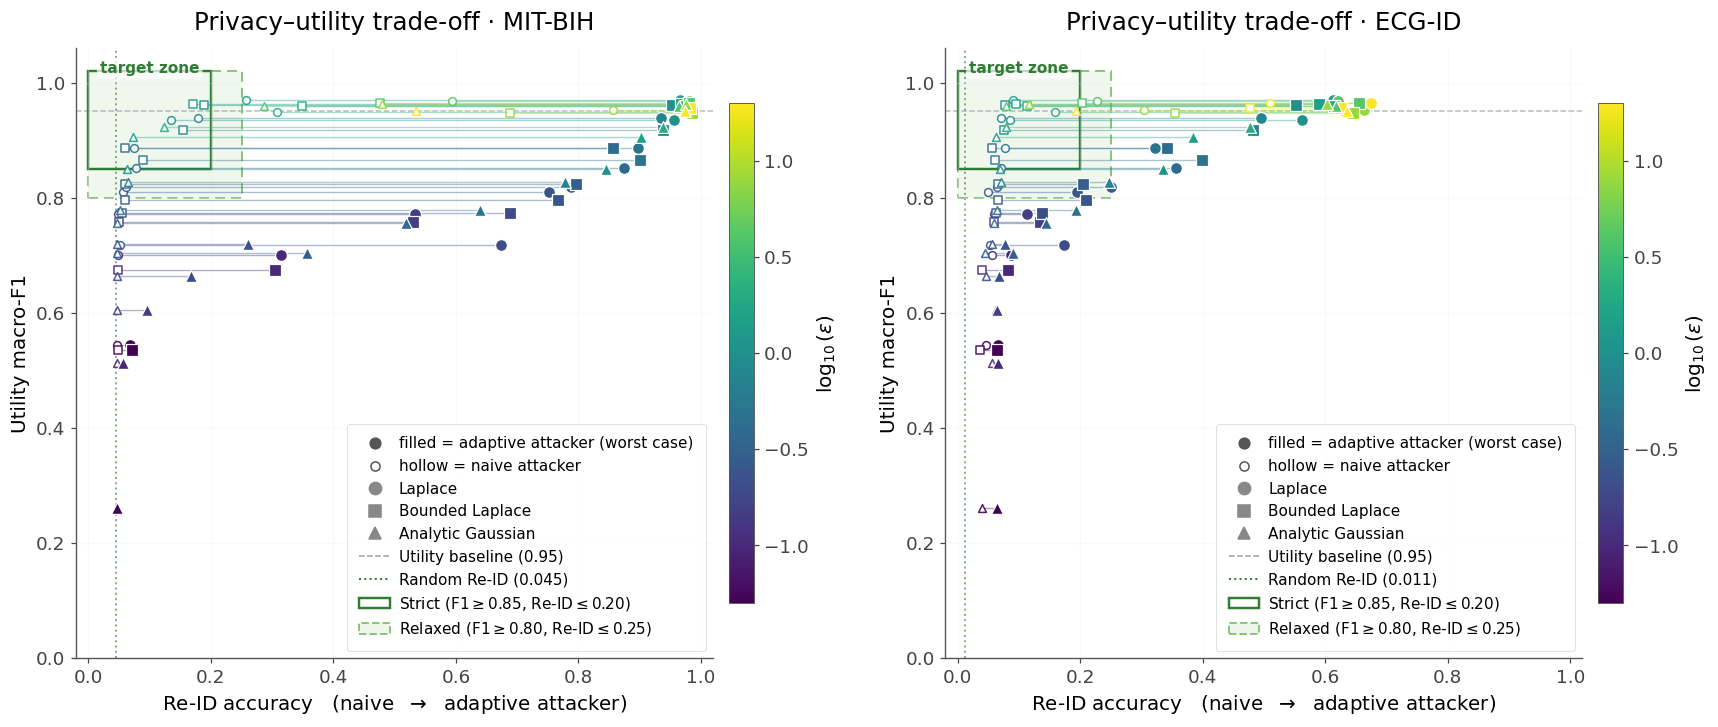

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

# Cleaner global style
mpl.rcParams.update({
    'font.size': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#555555', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.color': '#ededed', 'grid.linewidth': 0.8,
    'xtick.color': '#444444', 'ytick.color': '#444444',
    'axes.titlesize': 16, 'axes.titlepad': 12,
    'axes.labelsize': 13,
})

# Acceptance bars from the paper (read against the strong/adaptive attacker)
STRICT  = {'util': 0.85, 'reid': 0.20}
RELAXED = {'util': 0.80, 'reid': 0.25}


def build_segments(reid_agg_db, util_agg_in):
    naive = (reid_agg_db[reid_agg_db['threat_model'] == 'clean_attacker']
             [['mechanism','eps','delta','reid_mean','reid_std']]
             .rename(columns={'reid_mean': 'naive_mean', 'reid_std': 'naive_std'}))
    adapt = (reid_agg_db[reid_agg_db['threat_model'] == 'adaptive_attacker']
             [['mechanism','eps','delta','reid_mean','reid_std']]
             .rename(columns={'reid_mean': 'adapt_mean', 'reid_std': 'adapt_std'}))
    seg = naive.merge(adapt, on=['mechanism','eps','delta'], how='inner')
    seg = seg.merge(util_agg_in, on=['mechanism','eps','delta'], how='inner')
    return seg


def draw_zones(ax):
    # Relaxed zone: light fill + dashed border
    ax.add_patch(Rectangle((0, RELAXED['util']), RELAXED['reid'], 1.02 - RELAXED['util'],
                 facecolor='#eef6ea', alpha=0.85, edgecolor='none', zorder=0))
    ax.add_patch(Rectangle((0, RELAXED['util']), RELAXED['reid'], 1.02 - RELAXED['util'],
                 facecolor='none', edgecolor='#8cc47c', linestyle=(0, (5, 3)),
                 linewidth=1.3, zorder=1.4))
    # Strict zone: crisp solid border, no extra fill
    ax.add_patch(Rectangle((0, STRICT['util']), STRICT['reid'], 1.02 - STRICT['util'],
                 facecolor='none', edgecolor='#2e7d32', linewidth=1.6, zorder=1.5))
    # small label high inside the box, centered over the strict zone width
    ax.text(STRICT['reid'] / 2, 1.025, 'target zone',
            color='#2e7d32', fontsize=10, fontweight='bold',
            ha='center', va='center', zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='none', alpha=0.7))


seg_mit = build_segments(reid_mit_agg, util_agg)
seg_ecg = build_segments(reid_ecg_agg, util_agg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.8))

for ax, seg, ds_label, random_acc in zip(
        axes, [seg_mit, seg_ecg], ['MIT-BIH', 'ECG-ID'],
        [reid_mit_random, reid_ecg_random]):

    if seg.empty:
        ax.set_title(f'{ds_label} (no naive-attacker data)')
        continue

    eps_vals = sorted(seg['eps'].unique())
    log_eps = np.log10(np.array(eps_vals))
    norm = plt.Normalize(vmin=log_eps.min(), vmax=log_eps.max())
    cmap = plt.cm.viridis

    draw_zones(ax)

    for mech in MECH_LABELS:
        sub = seg[seg['mechanism'] == mech]
        if sub.empty:
            continue
        for _, row in sub.iterrows():
            col = cmap(norm(np.log10(row['eps'])))
            # connecting segment: thin, soft — a trace, not a feature
            ax.plot([row['naive_mean'], row['adapt_mean']], [row['util_mean']] * 2,
                    color=col, linewidth=0.9, alpha=0.4,
                    solid_capstyle='round', zorder=2)
            # adaptive end (worst case) — filled primary marker, white edge
            ax.scatter(row['adapt_mean'], row['util_mean'], marker=MECH_MARKERS[mech],
                       color=col, s=60, edgecolor='white', linewidth=0.8, zorder=4)
            # naive end — hollow secondary marker
            ax.scatter(row['naive_mean'], row['util_mean'], marker=MECH_MARKERS[mech],
                       facecolor='white', edgecolor=col, s=26, linewidth=1.0,
                       alpha=0.9, zorder=3)

    if not np.isnan(util_baseline_macro):
        ax.axhline(util_baseline_macro, color='#9aa0a6', linestyle='--',
                   linewidth=1.0, alpha=0.7, zorder=1)
    if not np.isnan(random_acc):
        ax.axvline(random_acc, color='#2e7d32', linestyle=':',
                   linewidth=1.3, alpha=0.6, zorder=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, label=r'$\log_{10}(\varepsilon)$', shrink=0.82, pad=0.02)
    cbar.outline.set_linewidth(0.6)

    ax.set_xlabel(r'Re-ID accuracy   (naive  $\rightarrow$  adaptive attacker)')
    ax.set_ylabel('Utility macro-F1')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 1.06)
    ax.set_title(f'Privacy–utility trade-off · {ds_label}')

    # ---- legend: attacker encoding stated first via filled / hollow ----
    fill_h = [Line2D([0], [0], marker='o', color='none', markerfacecolor='#555',
                     markeredgecolor='white', markersize=9,
                     label='filled = adaptive attacker (worst case)'),
              Line2D([0], [0], marker='o', color='none', markerfacecolor='white',
                     markeredgecolor='#555', markersize=6,
                     label='hollow = naive attacker')]
    mech_h = [Line2D([0], [0], marker=MECH_MARKERS[m], color='none', markerfacecolor='#888',
              markeredgecolor='#888', markersize=8, label=MECH_LABELS[m]) for m in MECH_LABELS]
    ref_h = [Line2D([0], [0], color='#9aa0a6', linestyle='--', linewidth=1.0,
                    label=f'Utility baseline ({util_baseline_macro:.2f})'),
             Line2D([0], [0], color='#2e7d32', linestyle=':', linewidth=1.3,
                    label=f'Random Re-ID ({random_acc:.3f})')]
    zone_h = [Patch(facecolor='none', edgecolor='#2e7d32', linewidth=1.6,
                    label=r'Strict (F1$\geq$0.85, Re-ID$\leq$0.20)'),
              Patch(facecolor='#eef6ea', edgecolor='#8cc47c', linestyle='--', linewidth=1.3,
                    label=r'Relaxed (F1$\geq$0.80, Re-ID$\leq$0.25)')]
    leg = ax.legend(handles=fill_h + mech_h + ref_h + zone_h, loc='lower right',
                    fontsize=10, framealpha=0.96, edgecolor='#dddddd',
                    borderpad=0.8, labelspacing=0.5, handletextpad=0.6)
    leg.get_frame().set_linewidth(0.6)

fig.tight_layout()
fig.savefig(FIGURES / 'money_figure_attacker_band.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'money_figure_attacker_band.png', dpi=200, bbox_inches='tight')
plt.show()

## Quantitative summary

For each (mech, eps), report naive Re-ID, adaptive Re-ID, and the gap
between them. A small gap = privacy guarantee robust to attacker
sophistication. A large gap = adaptive attacker substantially outperforms
naive one, meaning the published-noise approach is leaking information
that can be exploited by anyone who anticipates it.

In [7]:
def summarize_gap(seg, label):
    if seg.empty:
        print(f'{label}: no data\n'); return
    s = seg.copy()
    s['gap'] = s['adapt_mean'] - s['naive_mean']
    s['relative_gap'] = s['gap'] / s['adapt_mean'].replace(0, np.nan)
    print(f'\n=== {label}: naive vs adaptive Re-ID gap ===')
    print(s[['mechanism', 'eps', 'naive_mean', 'adapt_mean', 'gap', 'util_mean']]
          .round(3).to_string(index=False))
    print()
    print(f'  Overall mean gap:    {s["gap"].mean():.3f}')
    print(f'  Overall median gap:  {s["gap"].median():.3f}')
    print(f'  Max gap config:')
    worst = s.loc[s['gap'].idxmax()]
    print(f'    {worst["mechanism"]} eps={worst["eps"]}: '
          f'naive={worst["naive_mean"]:.3f}, adapt={worst["adapt_mean"]:.3f}, '
          f'gap={worst["gap"]:.3f}')

summarize_gap(seg_mit, 'MIT-BIH')
summarize_gap(seg_ecg, 'ECG-ID')


=== MIT-BIH: naive vs adaptive Re-ID gap ===
        mechanism   eps  naive_mean  adapt_mean   gap  util_mean
gaussian_analytic  0.05       0.046       0.047 0.000      0.260
gaussian_analytic  0.10       0.046       0.057 0.011      0.513
gaussian_analytic  0.15       0.047       0.096 0.048      0.606
gaussian_analytic  0.20       0.047       0.168 0.121      0.664
gaussian_analytic  0.25       0.047       0.260 0.213      0.719
gaussian_analytic  0.30       0.047       0.356 0.309      0.705
gaussian_analytic  0.40       0.047       0.519 0.471      0.757
gaussian_analytic  0.50       0.051       0.639 0.587      0.778
gaussian_analytic  0.75       0.064       0.779 0.714      0.827
gaussian_analytic  1.00       0.063       0.844 0.781      0.850
gaussian_analytic  1.50       0.073       0.902 0.829      0.905
gaussian_analytic  2.00       0.123       0.939 0.816      0.923
gaussian_analytic  4.00       0.287       0.965 0.677      0.960
gaussian_analytic  8.00       0.480       0.

## Export combined summary

In [8]:
out_rows = []
for seg, db_label in [(seg_mit, 'mitbih'), (seg_ecg, 'ecgid')]:
    if seg.empty:
        continue
    s = seg.copy()
    s['gap'] = s['adapt_mean'] - s['naive_mean']
    s['database'] = db_label
    out_rows.append(s[['database', 'mechanism', 'eps', 'delta',
                       'util_mean', 'util_std',
                       'naive_mean', 'naive_std',
                       'adapt_mean', 'adapt_std', 'gap']])

if out_rows:
    combined = pd.concat(out_rows, ignore_index=True)
    out_path = RESULTS / 'attacker_band_summary.csv'
    combined.to_csv(out_path, index=False)
    print(f'Saved: {out_path}')
    print(f'Rows: {len(combined)}')
    combined.head().round(3)
else:
    print('No combined data to export.')

Saved: ../results/attacker_band_summary.csv
Rows: 90
